# LLM Call Failure Statistics Analysis

This notebook analyzes the failure statistics from llm_calls.txt files in the LASR runs.

## Log Format
The llm_calls.txt files contain operation logs in the following format:
- Success: `[operation] content`  (e.g., `[mutate] (sin(x) + cos(y))`)
- Failure: `[operation|failed] content`  (e.g., `[mutate|failed] None`)

Where operation can be: `ideas`, `gen_random`, `mutate`, or `crossover`

## Pairing Logic
When two consecutive operations of the same type appear, they are grouped as a pair.
If either operation in the pair fails, the entire pair is marked as failed.

In [185]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

# Define experiment labels - extended to include all experiments
base_path = "lasr_runs_synthetic_llama32/"
dataset_type = "syn/failure_plot"  # For saving plots

exp_labels = {
    0: 'Llama3.2',
    1: 'Llama3.2 p',
    2: 'Llama3.2 ph',
    3: 'Llama3.2 phw',
    4: 'Qwen3-8B',
    5: 'Qwen3-8B-think',
    6: 'DeepSeek V3',
    7: 'DeepSeek R1',
    8: 'Llama3.2 p^w*',
    9: 'Qwen3-8B w*',
    10: 'Llama3.2 p*',
    11: 'Qwen3-8B p*',
    12: 'Qwen3-8B-think p*',
    13: 'DeepSeek V3 p*',
    14: 'DeepSeek R1 p^',
    15: 'Qwen3-8B-think p^w*',
    16: 'DeepSeek V3 p^w*'
}

# Syn2
base_path = "lasr_syn2/"
dataset_type = "syn2/failure_plot"  # For saving plots

exp_labels = {
    0: 'Llama3.2',
    1: 'Qwen3-8B',
    2: 'Qwen3-8B-think',
    3: 'DeepSeek V3',
    4: 'DeepSeek R1',
}

# Function to auto-detect available experiments
def detect_available_experiments(base_path):
    """Auto-detect all available exp_N directories and check if they have data."""
    base_path = Path(base_path)
    available_experiments = []
    
    # Find all exp_N directories
    exp_dirs = [d for d in base_path.iterdir() if d.is_dir() and d.name.startswith('exp_')]
    
    for exp_dir in sorted(exp_dirs):
        try:
            exp_num = int(exp_dir.name.replace('exp_', ''))
            
            # Check if this experiment has actual data (equation directories)
            eq_dirs = [d for d in exp_dir.iterdir() if d.is_dir() and d.name.isdigit()]
            
            if eq_dirs:
                # Check if at least one equation directory has llm_calls.txt
                has_data = False
                for eq_dir in eq_dirs:
                    if (eq_dir / "llm_calls.txt").exists():
                        has_data = True
                        break
                
                if has_data:
                    available_experiments.append(exp_num)
                    print(f"✓ Found experiment {exp_num} with data ({len(eq_dirs)} equations)")
                else:
                    print(f"! Found experiment {exp_num} but no llm_calls.txt files")
            else:
                print(f"! Found experiment {exp_num} but no equation directories")
                
        except ValueError:
            print(f"! Skipping non-numeric experiment directory: {exp_dir.name}")
    
    return sorted(available_experiments)

print("Experiment Detection:")
print("="*50)

Experiment Detection:


In [186]:
def count_patterns_in_file(file_path):
    """Count [ideas], [gen_random], [mutate], [crossover] patterns and their failures in a file.
    
    Based on the actual logging format:
    - Success: [operation] content
    - Failure: [operation|failed] content
    
    Pairing logic:
    - mutate/crossover: Group consecutive operations as pairs (retry mechanism)
    - ideas/gen_random: Usually single operations, but still check for pairs
    
    If any operation in a pair fails, mark the entire pair as failed.
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        
        import re
        
        # Find all operation lines with their type and status
        operations = []
        
        for i, line in enumerate(lines):
            line = line.strip()
            
            # Pattern for successful operations: [operation] content
            success_match = re.match(r'^\[(ideas|gen_random|mutate|crossover)\]\s*(.*)$', line)
            if success_match:
                operations.append({
                    'type': success_match.group(1),
                    'failed': False,
                    'content': success_match.group(2),
                    'line_num': i
                })
                continue
            
            # Pattern for failed operations: [operation|failed] content
            failed_match = re.match(r'^\[(ideas|gen_random|mutate|crossover)\|failed\]\s*(.*)$', line)
            if failed_match:
                operations.append({
                    'type': failed_match.group(1),
                    'failed': True,
                    'content': failed_match.group(2),
                    'line_num': i
                })
        
        # Group consecutive operations of the same type
        grouped_operations = []
        i = 0
        
        while i < len(operations):
            current = operations[i]
            
            # Check if there's a next operation of the same type that's consecutive
            # For mutate/crossover: more likely to have pairs (retry mechanism)
            # For ideas/gen_random: less likely, but still check
            max_line_gap = 20 if current['type'] in ['mutate', 'crossover'] else 10
            
            if (i + 1 < len(operations) and 
                operations[i + 1]['type'] == current['type'] and
                operations[i + 1]['line_num'] - current['line_num'] < max_line_gap):
                
                # This is a pair of consecutive operations
                next_op = operations[i + 1]
                
                # If either operation failed, the pair failed
                pair_failed = current['failed'] or next_op['failed']
                
                grouped_operations.append({
                    'type': current['type'],
                    'failed': pair_failed,
                    'is_pair': True,
                    'count': 2,  # This represents 2 operations grouped as 1 unit
                    'details': f"Pair: {'FAIL' if current['failed'] else 'OK'} + {'FAIL' if next_op['failed'] else 'OK'} = {'FAIL' if pair_failed else 'OK'}"
                })
                
                i += 2  # Skip both operations as they're now grouped
            else:
                # Single operation (not part of a consecutive pair)
                grouped_operations.append({
                    'type': current['type'],
                    'failed': current['failed'],
                    'is_pair': False,
                    'count': 1,  # Single operation
                    'details': f"Single: {'FAIL' if current['failed'] else 'OK'}"
                })
                
                i += 1
        
        # Count the results
        counts = {
            'ideas_success': 0,
            'ideas_failed': 0,
            'gen_random_success': 0,
            'gen_random_failed': 0,
            'mutate_success': 0,
            'mutate_failed': 0,
            'crossover_success': 0,
            'crossover_failed': 0
        }
        
        # Also track detailed statistics
        operation_details = {
            'ideas': {'single': 0, 'pairs': 0, 'total_ops': 0},
            'gen_random': {'single': 0, 'pairs': 0, 'total_ops': 0},
            'mutate': {'single': 0, 'pairs': 0, 'total_ops': 0},
            'crossover': {'single': 0, 'pairs': 0, 'total_ops': 0}
        }
        
        for group in grouped_operations:
            op_type = group['type']
            
            # Count success/failure
            if group['failed']:
                key = f"{op_type}_failed"
            else:
                key = f"{op_type}_success"
            
            if key in counts:
                counts[key] += 1
            
            # Track pairing statistics
            if group['is_pair']:
                operation_details[op_type]['pairs'] += 1
                operation_details[op_type]['total_ops'] += 2
            else:
                operation_details[op_type]['single'] += 1
                operation_details[op_type]['total_ops'] += 1
        
        # Add detailed stats to return (for debugging)
        counts['_debug_details'] = operation_details
        counts['_debug_groups'] = grouped_operations
        
        return counts
        
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return {
            'ideas_success': 0,
            'ideas_failed': 0,
            'gen_random_success': 0,
            'gen_random_failed': 0,
            'mutate_success': 0,
            'mutate_failed': 0,
            'crossover_success': 0,
            'crossover_failed': 0,
            '_debug_details': {},
            '_debug_groups': []
        }

In [187]:
def scan_lasr_runs(base_path, available_experiments=None):
    """Scan the LASR runs directory and collect statistics."""
    base_path = Path(base_path)
    results = []
    
    # Auto-detect experiments if not provided
    if available_experiments is None:
        available_experiments = detect_available_experiments(base_path)
    
    print(f"\nProcessing {len(available_experiments)} experiments: {available_experiments}")
    
    # Scan all available experiments
    for exp_num in available_experiments:
        exp_dir = base_path / f"exp_{exp_num}"
        if not exp_dir.exists():
            print(f"Warning: exp_{exp_num} directory not found")
            continue
            
        # Scan equation 1 to 10 (standard range)
        for eq_num in range(1, 11):
            eq_dir = exp_dir / str(eq_num)
            llm_calls_file = eq_dir / "llm_calls.txt"
            
            if llm_calls_file.exists():
                counts = count_patterns_in_file(llm_calls_file)
                
                # Calculate totals and failure rates for each operation type
                ideas_total = counts['ideas_success'] + counts['ideas_failed']
                gen_random_total = counts['gen_random_success'] + counts['gen_random_failed']
                mutate_total = counts['mutate_success'] + counts['mutate_failed']
                crossover_total = counts['crossover_success'] + counts['crossover_failed']
                
                ideas_failure_rate = counts['ideas_failed'] / ideas_total if ideas_total > 0 else 0
                gen_random_failure_rate = counts['gen_random_failed'] / gen_random_total if gen_random_total > 0 else 0
                mutate_failure_rate = counts['mutate_failed'] / mutate_total if mutate_total > 0 else 0
                crossover_failure_rate = counts['crossover_failed'] / crossover_total if crossover_total > 0 else 0
                
                # Overall statistics
                total_operations = ideas_total + gen_random_total + mutate_total + crossover_total
                total_failures = counts['ideas_failed'] + counts['gen_random_failed'] + counts['mutate_failed'] + counts['crossover_failed']
                overall_failure_rate = total_failures / total_operations if total_operations > 0 else 0
                
                results.append({
                    'experiment': exp_num,
                    'equation': eq_num,
                    # Ideas statistics
                    'ideas_success': counts['ideas_success'],
                    'ideas_failed': counts['ideas_failed'],
                    'ideas_total': ideas_total,
                    'ideas_failure_rate': ideas_failure_rate,
                    # Gen random statistics
                    'gen_random_success': counts['gen_random_success'],
                    'gen_random_failed': counts['gen_random_failed'],
                    'gen_random_total': gen_random_total,
                    'gen_random_failure_rate': gen_random_failure_rate,
                    # Mutate statistics
                    'mutate_success': counts['mutate_success'],
                    'mutate_failed': counts['mutate_failed'],
                    'mutate_total': mutate_total,
                    'mutate_failure_rate': mutate_failure_rate,
                    # Crossover statistics
                    'crossover_success': counts['crossover_success'],
                    'crossover_failed': counts['crossover_failed'],
                    'crossover_total': crossover_total,
                    'crossover_failure_rate': crossover_failure_rate,
                    # Overall statistics
                    'total_operations': total_operations,
                    'total_failures': total_failures,
                    'overall_failure_rate': overall_failure_rate
                })
            else:
                print(f"Missing file: exp_{exp_num}/eq_{eq_num}/llm_calls.txt")
    
    return pd.DataFrame(results)

In [188]:
# Debug: Analyze operation pairing patterns
test_file = Path("lasr_runs_synthetic_llama32/exp_0/1/llm_calls.txt")
if test_file.exists():
    print(f"Testing operation pairing on: {test_file}")
    test_counts = count_patterns_in_file(test_file)
    
    print("\nOperation Counts:")
    for key, value in test_counts.items():
        if not key.startswith('_') and value > 0:
            print(f"  {key}: {value}")
    
    if '_debug_details' in test_counts:
        print("\nPairing Pattern Analysis:")
        details = test_counts['_debug_details']
        for op_type, stats in details.items():
            if stats['total_ops'] > 0:
                print(f"\n{op_type.upper()}:")
                print(f"  Single operations: {stats['single']}")
                print(f"  Paired operations: {stats['pairs']} pairs (= {stats['pairs']*2} individual ops)")
                print(f"  Total operations processed: {stats['total_ops']}")
                print(f"  Final count units: {stats['single'] + stats['pairs']}")
    
    if '_debug_groups' in test_counts:
        print("\nFirst 10 Operation Groups Found:")
        groups = test_counts['_debug_groups'][:10]
        for i, group in enumerate(groups):
            print(f"  {i+1}. {group['type']:10} - {group['details']}")
            
    print("\n" + "="*60)
    print("ANALYSIS:")
    print("- ideas/gen_random应该主要是单次操作")
    print("- mutate/crossover可能有重试机制，出现配对")
    print("- 配对的操作算作1个单元，单次操作也算1个单元")
else:
    print(f"Test file not found: {test_file}")
    
    # Try to find any available file
    base_path = Path("lasr_runs_synthetic_llama32")
    if base_path.exists():
        print(f"\nSearching for available llm_calls.txt files...")
        found_files = list(base_path.rglob("llm_calls.txt"))
        if found_files:
            print(f"Found {len(found_files)} files. Testing first one:")
            test_counts = count_patterns_in_file(found_files[0])
            print(f"Counts: {[f'{k}:{v}' for k,v in test_counts.items() if not k.startswith('_') and v > 0]}")
        else:
            print("No llm_calls.txt files found in the directory structure.")

Testing operation pairing on: lasr_runs_synthetic_llama32/exp_0/1/llm_calls.txt

Operation Counts:
  ideas_success: 7
  ideas_failed: 3
  mutate_success: 2
  mutate_failed: 3

Pairing Pattern Analysis:

IDEAS:
  Single operations: 3
  Paired operations: 7 pairs (= 14 individual ops)
  Total operations processed: 17
  Final count units: 10

MUTATE:
  Single operations: 0
  Paired operations: 5 pairs (= 10 individual ops)
  Total operations processed: 10
  Final count units: 5

First 10 Operation Groups Found:
  1. mutate     - Pair: FAIL + OK = FAIL
  2. ideas      - Pair: OK + OK = OK
  3. ideas      - Pair: OK + OK = OK
  4. ideas      - Pair: OK + OK = OK
  5. ideas      - Pair: OK + OK = OK
  6. ideas      - Single: FAIL
  7. mutate     - Pair: FAIL + OK = FAIL
  8. mutate     - Pair: OK + OK = OK
  9. ideas      - Single: FAIL
  10. ideas      - Pair: OK + OK = OK

ANALYSIS:
- ideas/gen_random应该主要是单次操作
- mutate/crossover可能有重试机制，出现配对
- 配对的操作算作1个单元，单次操作也算1个单元


In [189]:
# Set the base path and verify structure

# First, let's check if the directory exists and examine its structure
from pathlib import Path
base_path_obj = Path(base_path)

if base_path_obj.exists():
    print(f"Base path exists: {base_path_obj.absolute()}")
    
    # Auto-detect available experiments
    available_experiments = detect_available_experiments(base_path)
    
    print(f"\nAvailable experiments with data: {available_experiments}")
    print(f"Total: {len(available_experiments)} experiments")
    
    # Show experiment labels
    print("\nExperiment Labels:")
    for exp_num in available_experiments:
        label = exp_labels.get(exp_num, f"Exp_{exp_num}")
        print(f"  exp_{exp_num}: {label}")
    
    # Check for equation directories in first few experiments
    print(f"\nDetailed structure check:")
    for exp_num in available_experiments[:3]:  # Show first 3
        exp_dir = base_path_obj / f"exp_{exp_num}"
        print(f"  {exp_dir.name}")
        
        # Check for equation directories
        eq_dirs = sorted([d for d in exp_dir.iterdir() if d.is_dir() and d.name.isdigit()])
        if eq_dirs:
            print(f"    Contains {len(eq_dirs)} equation directories: {[d.name for d in eq_dirs]}")
            # Check for llm_calls.txt in first equation dir
            first_eq = eq_dirs[0]
            llm_file = first_eq / "llm_calls.txt"
            if llm_file.exists():
                print(f"    ✓ {first_eq.name}/llm_calls.txt exists ({llm_file.stat().st_size} bytes)")
            else:
                print(f"    ✗ {first_eq.name}/llm_calls.txt NOT FOUND")
        else:
            print(f"    No equation directories found")
else:
    print(f"ERROR: Base path does not exist: {base_path}")
    print(f"Current working directory: {Path.cwd()}")

# Scan and collect data using detected experiments
print(f"\n" + "="*60)
print("SCANNING ALL AVAILABLE EXPERIMENTS")
print("="*60)

df = scan_lasr_runs(base_path, available_experiments)
print(f"\nCollected data for {len(df)} experiment-equation combinations")

if len(df) > 0:
    print("\nExperiment coverage:")
    exp_coverage = df['experiment'].value_counts().sort_index()
    for exp_num, count in exp_coverage.items():
        label = exp_labels.get(exp_num, f"Exp_{exp_num}")
        print(f"  exp_{exp_num} ({label}): {count} equations")
    
    print("\nFirst few rows:")
    print(df.head())
    
    # Check if we have any non-zero counts
    operation_cols = ['ideas_total', 'gen_random_total', 'mutate_total', 'crossover_total']
    print("\nOperation totals across all experiments:")
    for col in operation_cols:
        if col in df.columns:
            total = df[col].sum()
            print(f"  {col}: {total:,}")
else:
    print("\nNo data collected. Please check file paths and format.")

Base path exists: /Users/xiaobocheng/final_project/LibraryAugmentedSymbolicRegression.jl/lasr_syn2
✓ Found experiment 0 with data (7 equations)
✓ Found experiment 1 with data (10 equations)
✓ Found experiment 2 with data (5 equations)
✓ Found experiment 3 with data (10 equations)

Available experiments with data: [0, 1, 2, 3]
Total: 4 experiments

Experiment Labels:
  exp_0: Llama3.2
  exp_1: Qwen3-8B
  exp_2: Qwen3-8B-think
  exp_3: DeepSeek V3

Detailed structure check:
  exp_0
    Contains 7 equation directories: ['1', '2', '3', '4', '5', '6', '7']
    ✓ 1/llm_calls.txt exists (182588 bytes)
  exp_1
    Contains 10 equation directories: ['1', '10', '2', '3', '4', '5', '6', '7', '8', '9']
    ✓ 1/llm_calls.txt exists (119305 bytes)
  exp_2
    Contains 5 equation directories: ['1', '2', '3', '4', '5']
    ✓ 1/llm_calls.txt exists (167808 bytes)

SCANNING ALL AVAILABLE EXPERIMENTS

Processing 4 experiments: [0, 1, 2, 3]
Missing file: exp_0/eq_8/llm_calls.txt
Missing file: exp_0/eq_9/l

In [190]:
# Create separate NxM tables for each operation type (N=experiments, M=10 equations)
# N will be determined by the actual number of available experiments

available_experiments = sorted(df['experiment'].unique())
num_experiments = len(available_experiments)

print(f"Creating {num_experiments}x10 tables for {num_experiments} experiments: {available_experiments}")

ideas_failure_rate_table = df.pivot(index='experiment', columns='equation', values='ideas_failure_rate')
gen_random_failure_rate_table = df.pivot(index='experiment', columns='equation', values='gen_random_failure_rate')
mutate_failure_rate_table = df.pivot(index='experiment', columns='equation', values='mutate_failure_rate')
crossover_failure_rate_table = df.pivot(index='experiment', columns='equation', values='crossover_failure_rate')
overall_failure_rate_table = df.pivot(index='experiment', columns='equation', values='overall_failure_rate')

# Save all failure rate tables to CSV files
ideas_failure_rate_table.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/ideas_failure_rate_table.csv')
gen_random_failure_rate_table.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/gen_random_failure_rate_table.csv')
mutate_failure_rate_table.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/mutate_failure_rate_table.csv')
crossover_failure_rate_table.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/crossover_failure_rate_table.csv')
overall_failure_rate_table.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/overall_failure_rate_table.csv')

# Save failure rate tables to text file
tables_path = f'/Users/xiaobocheng/final_project/image/{dataset_type}/failure_rate_tables.txt'
with open(tables_path, 'w') as f:
    f.write(f"Ideas Failure Rate Table ({num_experiments}x10):\n")
    f.write(ideas_failure_rate_table.to_string() + "\n\n")
    
    f.write(f"Gen Random Failure Rate Table ({num_experiments}x10):\n")
    f.write(gen_random_failure_rate_table.to_string() + "\n\n")
    
    f.write(f"Mutate Failure Rate Table ({num_experiments}x10):\n")
    f.write(mutate_failure_rate_table.to_string() + "\n\n")
    
    f.write(f"Crossover Failure Rate Table ({num_experiments}x10):\n")
    f.write(crossover_failure_rate_table.to_string() + "\n\n")
    
    f.write(f"Overall Failure Rate Table ({num_experiments}x10):\n")
    f.write(overall_failure_rate_table.to_string() + "\n")

print(f"Ideas Failure Rate Table ({num_experiments}x10):")
print(ideas_failure_rate_table)
print(f"\nGen Random Failure Rate Table ({num_experiments}x10):")
print(gen_random_failure_rate_table)
print(f"\nMutate Failure Rate Table ({num_experiments}x10):")
print(mutate_failure_rate_table)
print(f"\nCrossover Failure Rate Table ({num_experiments}x10):")
print(crossover_failure_rate_table)
print(f"\nOverall Failure Rate Table ({num_experiments}x10):")
print(overall_failure_rate_table)

Creating 4x10 tables for 4 experiments: [0, 1, 2, 3]
Ideas Failure Rate Table (4x10):
equation     1    2    3    4    5    6     7    8    9    10
experiment                                                   
0           0.6  0.3  0.5  0.2  0.4  0.8  0.75  NaN  NaN  NaN
1           0.0  0.0  0.0  0.0  0.0  0.0  0.00  0.1  0.0  0.0
2           0.2  0.0  0.3  0.1  0.0  NaN   NaN  NaN  NaN  NaN
3           0.0  0.0  0.0  0.0  0.0  0.0  0.00  0.0  0.0  0.0

Gen Random Failure Rate Table (4x10):
equation     1    2    3    4    5    6    7    8    9    10
experiment                                                  
0           1.0  0.0  0.0  0.5  1.0  0.0  0.0  NaN  NaN  NaN
1           0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
2           0.0  0.5  0.0  0.0  0.5  NaN  NaN  NaN  NaN  NaN
3           0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0

Mutate Failure Rate Table (4x10):
equation          1         2         3         4         5         6   \
experiment                  

In [191]:
# Create total count tables for each operation type
ideas_total_table = df.pivot(index='experiment', columns='equation', values='ideas_total')
gen_random_total_table = df.pivot(index='experiment', columns='equation', values='gen_random_total')
mutate_total_table = df.pivot(index='experiment', columns='equation', values='mutate_total')
crossover_total_table = df.pivot(index='experiment', columns='equation', values='crossover_total')
overall_total_table = df.pivot(index='experiment', columns='equation', values='total_operations')

# Save all total count tables to CSV files
ideas_total_table.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/ideas_total_table.csv')
gen_random_total_table.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/gen_random_total_table.csv')
mutate_total_table.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/mutate_total_table.csv')
crossover_total_table.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/crossover_total_table.csv')
overall_total_table.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/overall_total_table.csv')

# Save total count tables to text file
count_tables_path = f'/Users/xiaobocheng/final_project/image/{dataset_type}/total_count_tables.txt'
with open(count_tables_path, 'w') as f:
    f.write("Ideas Total Count Table (8x10):\n")
    f.write(ideas_total_table.to_string() + "\n\n")
    
    f.write("Gen Random Total Count Table (8x10):\n")
    f.write(gen_random_total_table.to_string() + "\n\n")
    
    f.write("Mutate Total Count Table (8x10):\n")
    f.write(mutate_total_table.to_string() + "\n\n")
    
    f.write("Crossover Total Count Table (8x10):\n")
    f.write(crossover_total_table.to_string() + "\n\n")
    
    f.write("Overall Total Operations Table (8x10):\n")
    f.write(overall_total_table.to_string() + "\n")

print("Ideas Total Count Table (8x10):")
print(ideas_total_table)
print("\nGen Random Total Count Table (8x10):")
print(gen_random_total_table)
print("\nMutate Total Count Table (8x10):")
print(mutate_total_table)
print("\nCrossover Total Count Table (8x10):")
print(crossover_total_table)
print("\nOverall Total Operations Table (8x10):")
print(overall_total_table)

Ideas Total Count Table (8x10):
equation      1     2     3     4     5     6     7     8     9     10
experiment                                                            
0           10.0  10.0  10.0  10.0  10.0  10.0   4.0   NaN   NaN   NaN
1           10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0
2           10.0  10.0  10.0  10.0   8.0   NaN   NaN   NaN   NaN   NaN
3           10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0

Gen Random Total Count Table (8x10):
equation     1    2    3    4    5    6    7    8    9    10
experiment                                                  
0           1.0  0.0  0.0  4.0  2.0  0.0  0.0  NaN  NaN  NaN
1           0.0  1.0  1.0  3.0  1.0  0.0  0.0  2.0  0.0  3.0
2           0.0  2.0  1.0  0.0  2.0  NaN  NaN  NaN  NaN  NaN
3           3.0  2.0  1.0  1.0  2.0  0.0  2.0  0.0  1.0  1.0

Mutate Total Count Table (8x10):
equation      1     2     3     4     5     6     7     8     9     10
experiment                       

In [192]:
# Summary by experiment (method) for each operation type
method_summary_ideas = df.groupby('experiment').agg({
    'ideas_failed': 'sum',
    'ideas_success': 'sum',
    'ideas_total': 'sum'
}).reset_index()
method_summary_ideas['ideas_failure_rate'] = method_summary_ideas['ideas_failed'] / method_summary_ideas['ideas_total']

method_summary_gen_random = df.groupby('experiment').agg({
    'gen_random_failed': 'sum',
    'gen_random_success': 'sum',
    'gen_random_total': 'sum'
}).reset_index()
method_summary_gen_random['gen_random_failure_rate'] = method_summary_gen_random['gen_random_failed'] / method_summary_gen_random['gen_random_total']

method_summary_mutate = df.groupby('experiment').agg({
    'mutate_failed': 'sum',
    'mutate_success': 'sum',
    'mutate_total': 'sum'
}).reset_index()
method_summary_mutate['mutate_failure_rate'] = method_summary_mutate['mutate_failed'] / method_summary_mutate['mutate_total']

method_summary_crossover = df.groupby('experiment').agg({
    'crossover_failed': 'sum',
    'crossover_success': 'sum',
    'crossover_total': 'sum'
}).reset_index()
method_summary_crossover['crossover_failure_rate'] = method_summary_crossover['crossover_failed'] / method_summary_crossover['crossover_total']

method_summary_overall = df.groupby('experiment').agg({
    'total_failures': 'sum',
    'total_operations': 'sum'
}).reset_index()
method_summary_overall['overall_failure_rate'] = method_summary_overall['total_failures'] / method_summary_overall['total_operations']

# Save all method summaries to CSV files
method_summary_ideas.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/method_summary_ideas.csv', index=False)
method_summary_gen_random.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/method_summary_gen_random.csv', index=False)
method_summary_mutate.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/method_summary_mutate.csv', index=False)
method_summary_crossover.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/method_summary_crossover.csv', index=False)
method_summary_overall.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/method_summary_overall.csv', index=False)

# Save method summaries to text file
method_summary_path = f'/Users/xiaobocheng/final_project/image/{dataset_type}/method_summaries.txt'
with open(method_summary_path, 'w') as f:
    f.write("Summary by Method (Experiment) - Ideas:\n")
    f.write(method_summary_ideas.to_string(index=False) + "\n\n")
    
    f.write("Summary by Method (Experiment) - Gen Random:\n")
    f.write(method_summary_gen_random.to_string(index=False) + "\n\n")
    
    f.write("Summary by Method (Experiment) - Mutate:\n")
    f.write(method_summary_mutate.to_string(index=False) + "\n\n")
    
    f.write("Summary by Method (Experiment) - Crossover:\n")
    f.write(method_summary_crossover.to_string(index=False) + "\n\n")
    
    f.write("Summary by Method (Experiment) - Overall:\n")
    f.write(method_summary_overall.to_string(index=False) + "\n")

print("Summary by Method (Experiment) - Ideas:")
print(method_summary_ideas)
print("\nSummary by Method (Experiment) - Gen Random:")
print(method_summary_gen_random)
print("\nSummary by Method (Experiment) - Mutate:")
print(method_summary_mutate)
print("\nSummary by Method (Experiment) - Crossover:")
print(method_summary_crossover)
print("\nSummary by Method (Experiment) - Overall:")
print(method_summary_overall)

Summary by Method (Experiment) - Ideas:
   experiment  ideas_failed  ideas_success  ideas_total  ideas_failure_rate
0           0            31             33           64            0.484375
1           1             1             99          100            0.010000
2           2             6             42           48            0.125000
3           3             0            100          100            0.000000

Summary by Method (Experiment) - Gen Random:
   experiment  gen_random_failed  gen_random_success  gen_random_total  \
0           0                  5                   2                 7   
1           1                  1                  10                11   
2           2                  2                   3                 5   
3           3                  0                  13                13   

   gen_random_failure_rate  
0                 0.714286  
1                 0.090909  
2                 0.400000  
3                 0.000000  

Summary by Method

In [193]:
# Summary by equation for each operation type
equation_summary_ideas = df.groupby('equation').agg({
    'ideas_failed': 'sum',
    'ideas_success': 'sum',
    'ideas_total': 'sum'
}).reset_index()
equation_summary_ideas['ideas_failure_rate'] = equation_summary_ideas['ideas_failed'] / equation_summary_ideas['ideas_total']

equation_summary_gen_random = df.groupby('equation').agg({
    'gen_random_failed': 'sum',
    'gen_random_success': 'sum',
    'gen_random_total': 'sum'
}).reset_index()
equation_summary_gen_random['gen_random_failure_rate'] = equation_summary_gen_random['gen_random_failed'] / equation_summary_gen_random['gen_random_total']

equation_summary_mutate = df.groupby('equation').agg({
    'mutate_failed': 'sum',
    'mutate_success': 'sum',
    'mutate_total': 'sum'
}).reset_index()
equation_summary_mutate['mutate_failure_rate'] = equation_summary_mutate['mutate_failed'] / equation_summary_mutate['mutate_total']

equation_summary_crossover = df.groupby('equation').agg({
    'crossover_failed': 'sum',
    'crossover_success': 'sum',
    'crossover_total': 'sum'
}).reset_index()
equation_summary_crossover['crossover_failure_rate'] = equation_summary_crossover['crossover_failed'] / equation_summary_crossover['crossover_total']

equation_summary_overall = df.groupby('equation').agg({
    'total_failures': 'sum',
    'total_operations': 'sum'
}).reset_index()
equation_summary_overall['overall_failure_rate'] = equation_summary_overall['total_failures'] / equation_summary_overall['total_operations']

# Save all equation summaries to CSV files
equation_summary_ideas.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/equation_summary_ideas.csv', index=False)
equation_summary_gen_random.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/equation_summary_gen_random.csv', index=False)
equation_summary_mutate.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/equation_summary_mutate.csv', index=False)
equation_summary_crossover.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/equation_summary_crossover.csv', index=False)
equation_summary_overall.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/equation_summary_overall.csv', index=False)

# Save equation summaries to text file
equation_summary_path = f'/Users/xiaobocheng/final_project/image/{dataset_type}/equation_summaries.txt'
with open(equation_summary_path, 'w') as f:
    f.write("Summary by Equation - Ideas:\n")
    f.write(equation_summary_ideas.to_string(index=False) + "\n\n")
    
    f.write("Summary by Equation - Gen Random:\n")
    f.write(equation_summary_gen_random.to_string(index=False) + "\n\n")
    
    f.write("Summary by Equation - Mutate:\n")
    f.write(equation_summary_mutate.to_string(index=False) + "\n\n")
    
    f.write("Summary by Equation - Crossover:\n")
    f.write(equation_summary_crossover.to_string(index=False) + "\n\n")
    
    f.write("Summary by Equation - Overall:\n")
    f.write(equation_summary_overall.to_string(index=False) + "\n")

print("Summary by Equation - Ideas:")
print(equation_summary_ideas)
print("\nSummary by Equation - Gen Random:")
print(equation_summary_gen_random)
print("\nSummary by Equation - Mutate:")
print(equation_summary_mutate)
print("\nSummary by Equation - Crossover:")
print(equation_summary_crossover)
print("\nSummary by Equation - Overall:")
print(equation_summary_overall)

Summary by Equation - Ideas:
   equation  ideas_failed  ideas_success  ideas_total  ideas_failure_rate
0         1             8             32           40            0.200000
1         2             3             37           40            0.075000
2         3             8             32           40            0.200000
3         4             3             37           40            0.075000
4         5             4             34           38            0.105263
5         6             8             22           30            0.266667
6         7             3             21           24            0.125000
7         8             1             19           20            0.050000
8         9             0             20           20            0.000000
9        10             0             20           20            0.000000

Summary by Equation - Gen Random:
   equation  gen_random_failed  gen_random_success  gen_random_total  \
0         1                  1                   3

Saved plot to /Users/xiaobocheng/final_project/image/syn2/failure_plot/llm_failure_stats_comprehensive.png


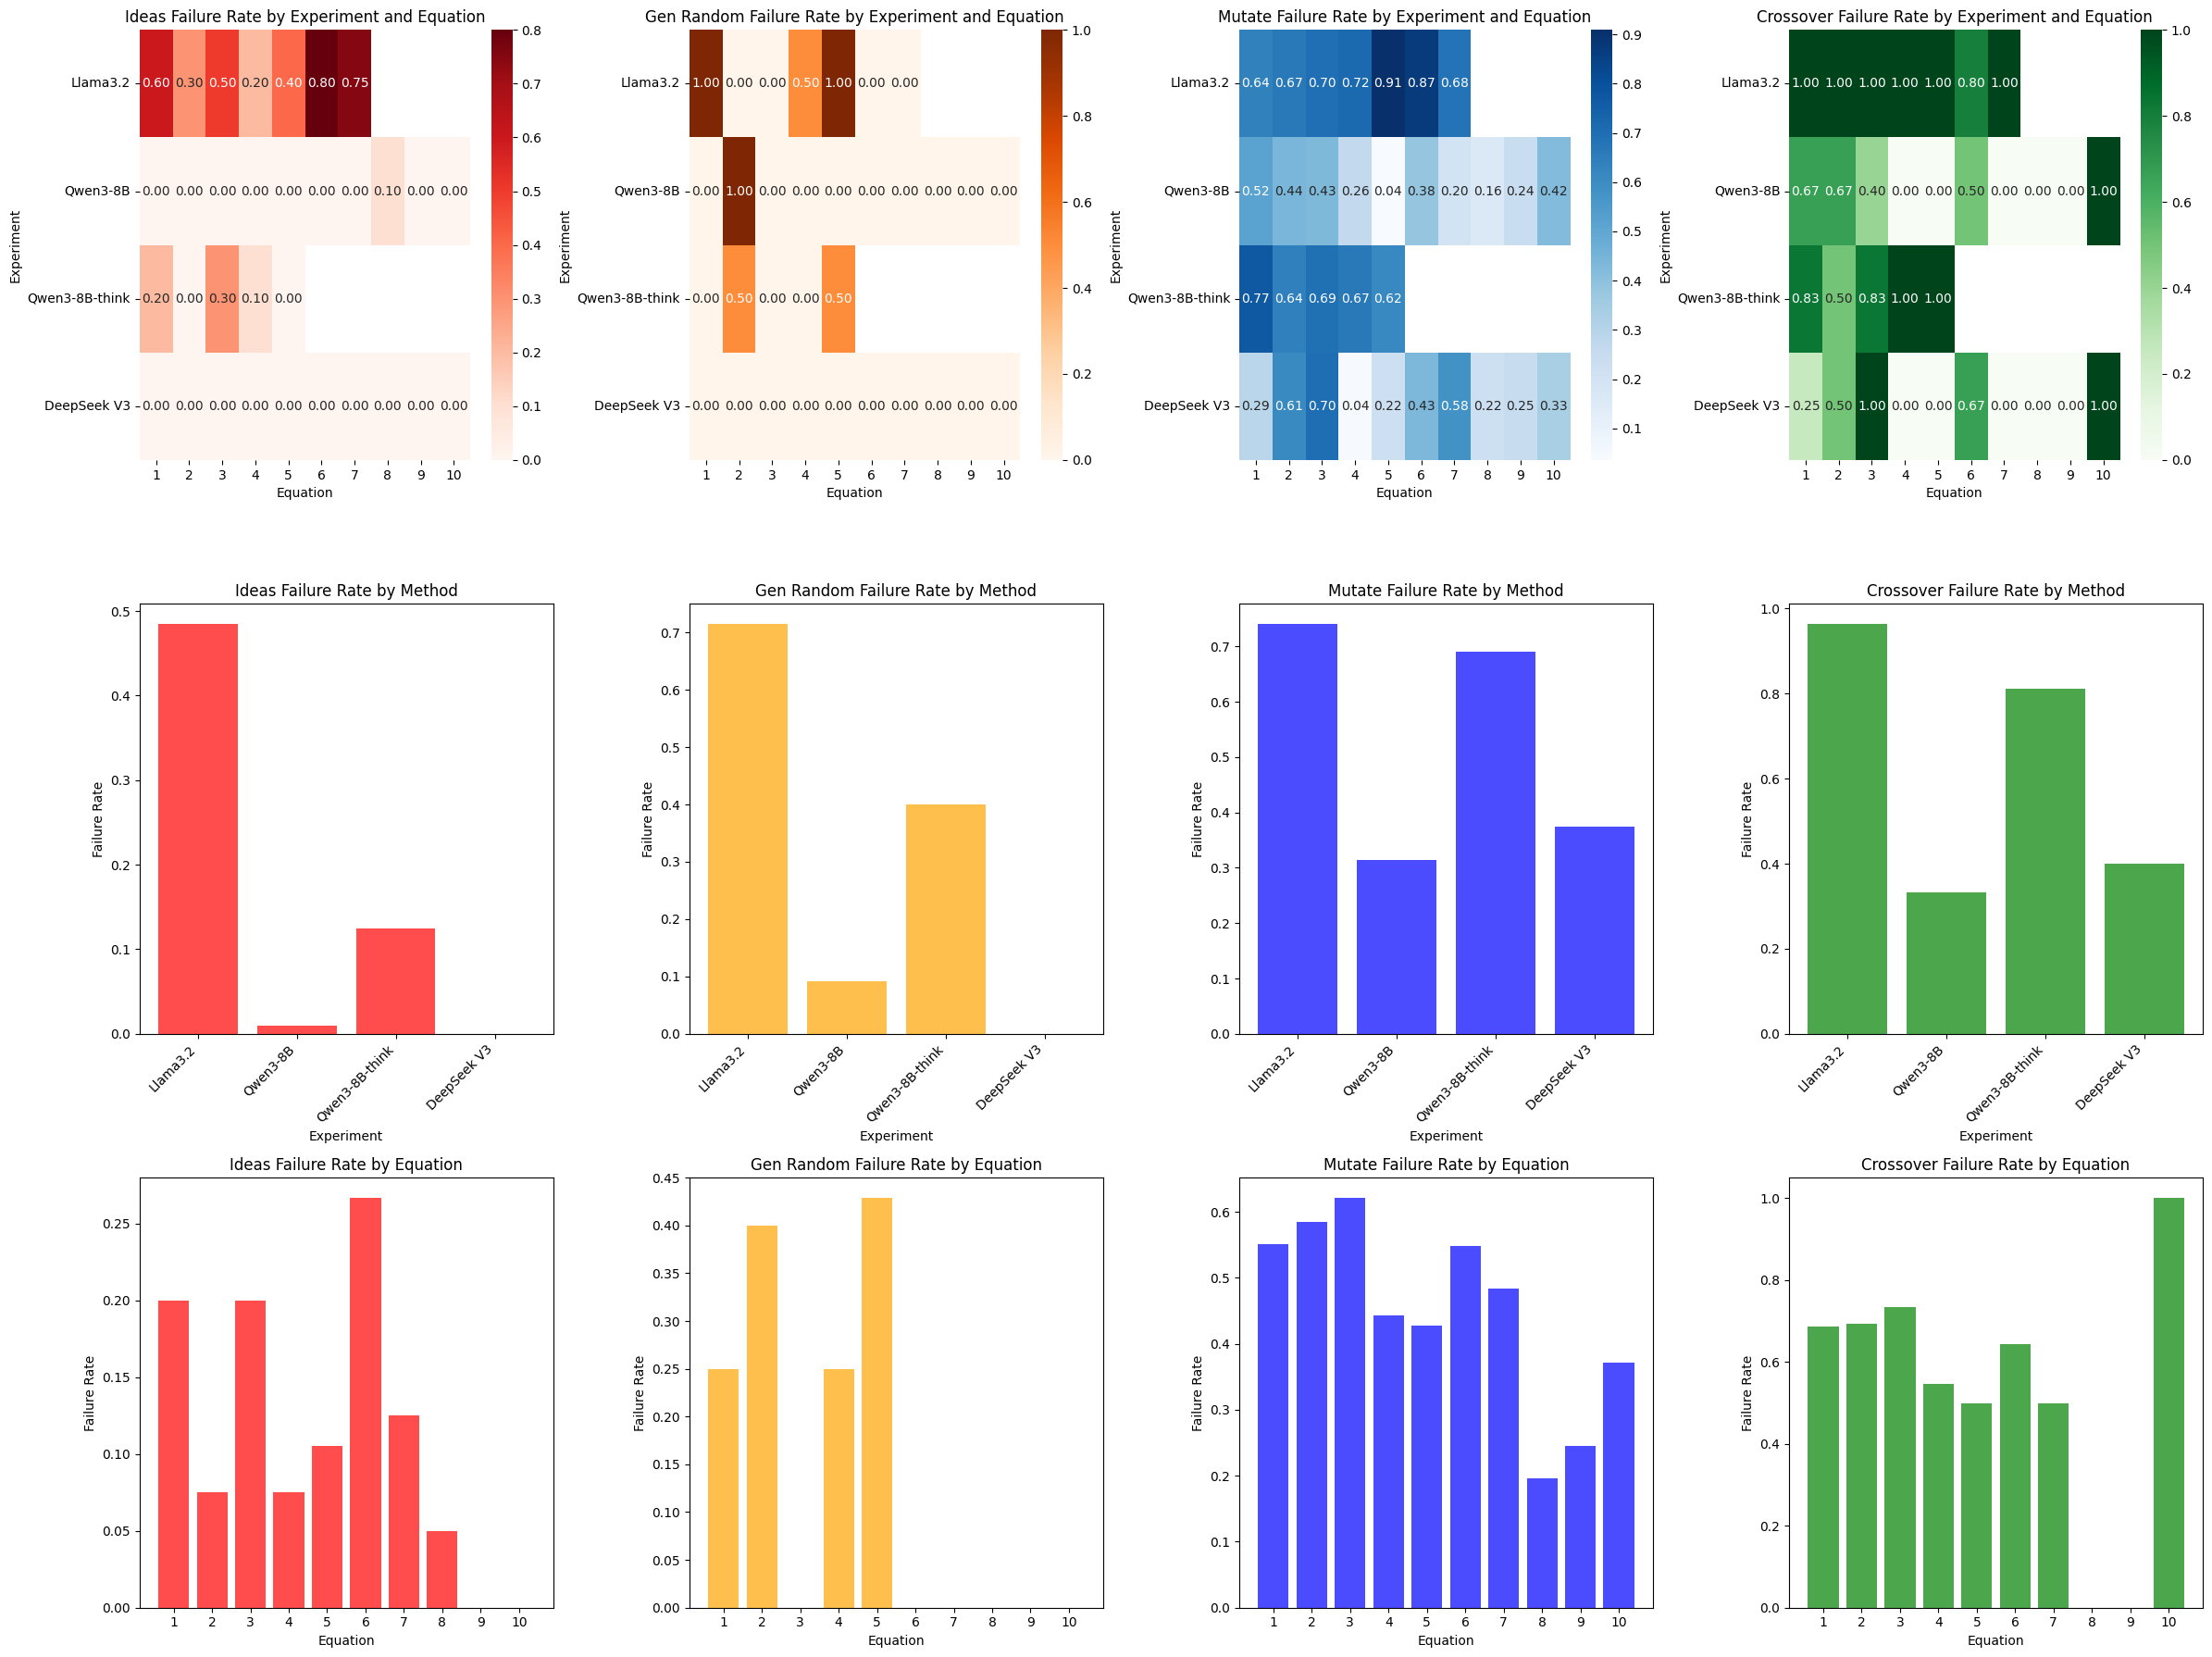


Visualization Summary:
- Processing 4 experiments: [0, 1, 2, 3]
- Experiment labels: ['Llama3.2', 'Qwen3-8B', 'Qwen3-8B-think', 'DeepSeek V3']
- Table dimensions: 4x10 (experiments x equations)


In [194]:
# Create comprehensive visualizations with dynamic experiment count
available_experiments = sorted(df['experiment'].unique())
num_experiments = len(available_experiments)

# Calculate appropriate figure size based on number of experiments
fig_height = max(18, num_experiments * 2)  # Minimum 18, scale with experiments
fig, axes = plt.subplots(3, 4, figsize=(24, fig_height))

# Create experiment labels for current experiments
current_exp_labels = [exp_labels.get(i, f'Exp_{i}') for i in available_experiments]

# Row 1: Heatmaps for each operation type
sns.heatmap(ideas_failure_rate_table, annot=True, fmt='.2f', cmap='Reds', ax=axes[0,0])
axes[0,0].set_title('Ideas Failure Rate by Experiment and Equation')
axes[0,0].set_xlabel('Equation')
axes[0,0].set_ylabel('Experiment')
axes[0,0].set_yticklabels(current_exp_labels, rotation=0)

sns.heatmap(gen_random_failure_rate_table, annot=True, fmt='.2f', cmap='Oranges', ax=axes[0,1])
axes[0,1].set_title('Gen Random Failure Rate by Experiment and Equation')
axes[0,1].set_xlabel('Equation')
axes[0,1].set_ylabel('Experiment')
axes[0,1].set_yticklabels(current_exp_labels, rotation=0)

sns.heatmap(mutate_failure_rate_table, annot=True, fmt='.2f', cmap='Blues', ax=axes[0,2])
axes[0,2].set_title('Mutate Failure Rate by Experiment and Equation')
axes[0,2].set_xlabel('Equation')
axes[0,2].set_ylabel('Experiment')
axes[0,2].set_yticklabels(current_exp_labels, rotation=0)

sns.heatmap(crossover_failure_rate_table, annot=True, fmt='.2f', cmap='Greens', ax=axes[0,3])
axes[0,3].set_title('Crossover Failure Rate by Experiment and Equation')
axes[0,3].set_xlabel('Equation')
axes[0,3].set_ylabel('Experiment')
axes[0,3].set_yticklabels(current_exp_labels, rotation=0)

# Row 2: Bar plots by method for each operation type
method_summary_ideas = df.groupby('experiment').agg({
    'ideas_failed': 'sum',
    'ideas_success': 'sum',
    'ideas_total': 'sum'
}).reset_index()
method_summary_ideas['ideas_failure_rate'] = method_summary_ideas['ideas_failed'] / method_summary_ideas['ideas_total']

method_summary_gen_random = df.groupby('experiment').agg({
    'gen_random_failed': 'sum',
    'gen_random_success': 'sum',
    'gen_random_total': 'sum'
}).reset_index()
method_summary_gen_random['gen_random_failure_rate'] = method_summary_gen_random['gen_random_failed'] / method_summary_gen_random['gen_random_total']

method_summary_mutate = df.groupby('experiment').agg({
    'mutate_failed': 'sum',
    'mutate_success': 'sum',
    'mutate_total': 'sum'
}).reset_index()
method_summary_mutate['mutate_failure_rate'] = method_summary_mutate['mutate_failed'] / method_summary_mutate['mutate_total']

method_summary_crossover = df.groupby('experiment').agg({
    'crossover_failed': 'sum',
    'crossover_success': 'sum',
    'crossover_total': 'sum'
}).reset_index()
method_summary_crossover['crossover_failure_rate'] = method_summary_crossover['crossover_failed'] / method_summary_crossover['crossover_total']

axes[1,0].bar(range(len(method_summary_ideas)), method_summary_ideas['ideas_failure_rate'], color='red', alpha=0.7)
axes[1,0].set_title('Ideas Failure Rate by Method')
axes[1,0].set_xlabel('Experiment')
axes[1,0].set_ylabel('Failure Rate')
axes[1,0].set_xticks(range(len(method_summary_ideas)))
axes[1,0].set_xticklabels(current_exp_labels, rotation=45, ha='right')

axes[1,1].bar(range(len(method_summary_gen_random)), method_summary_gen_random['gen_random_failure_rate'], color='orange', alpha=0.7)
axes[1,1].set_title('Gen Random Failure Rate by Method')
axes[1,1].set_xlabel('Experiment')
axes[1,1].set_ylabel('Failure Rate')
axes[1,1].set_xticks(range(len(method_summary_gen_random)))
axes[1,1].set_xticklabels(current_exp_labels, rotation=45, ha='right')

axes[1,2].bar(range(len(method_summary_mutate)), method_summary_mutate['mutate_failure_rate'], color='blue', alpha=0.7)
axes[1,2].set_title('Mutate Failure Rate by Method')
axes[1,2].set_xlabel('Experiment')
axes[1,2].set_ylabel('Failure Rate')
axes[1,2].set_xticks(range(len(method_summary_mutate)))
axes[1,2].set_xticklabels(current_exp_labels, rotation=45, ha='right')

axes[1,3].bar(range(len(method_summary_crossover)), method_summary_crossover['crossover_failure_rate'], color='green', alpha=0.7)
axes[1,3].set_title('Crossover Failure Rate by Method')
axes[1,3].set_xlabel('Experiment')
axes[1,3].set_ylabel('Failure Rate')
axes[1,3].set_xticks(range(len(method_summary_crossover)))
axes[1,3].set_xticklabels(current_exp_labels, rotation=45, ha='right')

# Row 3: Bar plots by equation for each operation type
equation_summary_ideas = df.groupby('equation').agg({
    'ideas_failed': 'sum',
    'ideas_success': 'sum',
    'ideas_total': 'sum'
}).reset_index()
equation_summary_ideas['ideas_failure_rate'] = equation_summary_ideas['ideas_failed'] / equation_summary_ideas['ideas_total']

equation_summary_gen_random = df.groupby('equation').agg({
    'gen_random_failed': 'sum',
    'gen_random_success': 'sum',
    'gen_random_total': 'sum'
}).reset_index()
equation_summary_gen_random['gen_random_failure_rate'] = equation_summary_gen_random['gen_random_failed'] / equation_summary_gen_random['gen_random_total']

equation_summary_mutate = df.groupby('equation').agg({
    'mutate_failed': 'sum',
    'mutate_success': 'sum',
    'mutate_total': 'sum'
}).reset_index()
equation_summary_mutate['mutate_failure_rate'] = equation_summary_mutate['mutate_failed'] / equation_summary_mutate['mutate_total']

equation_summary_crossover = df.groupby('equation').agg({
    'crossover_failed': 'sum',
    'crossover_success': 'sum',
    'crossover_total': 'sum'
}).reset_index()
equation_summary_crossover['crossover_failure_rate'] = equation_summary_crossover['crossover_failed'] / equation_summary_crossover['crossover_total']

axes[2,0].bar(equation_summary_ideas['equation'], equation_summary_ideas['ideas_failure_rate'], color='red', alpha=0.7)
axes[2,0].set_title('Ideas Failure Rate by Equation')
axes[2,0].set_xlabel('Equation')
axes[2,0].set_ylabel('Failure Rate')
axes[2,0].set_xticks(range(1, 11))

axes[2,1].bar(equation_summary_gen_random['equation'], equation_summary_gen_random['gen_random_failure_rate'], color='orange', alpha=0.7)
axes[2,1].set_title('Gen Random Failure Rate by Equation')
axes[2,1].set_xlabel('Equation')
axes[2,1].set_ylabel('Failure Rate')
axes[2,1].set_xticks(range(1, 11))

axes[2,2].bar(equation_summary_mutate['equation'], equation_summary_mutate['mutate_failure_rate'], color='blue', alpha=0.7)
axes[2,2].set_title('Mutate Failure Rate by Equation')
axes[2,2].set_xlabel('Equation')
axes[2,2].set_ylabel('Failure Rate')
axes[2,2].set_xticks(range(1, 11))

axes[2,3].bar(equation_summary_crossover['equation'], equation_summary_crossover['crossover_failure_rate'], color='green', alpha=0.7)
axes[2,3].set_title('Crossover Failure Rate by Equation')
axes[2,3].set_xlabel('Equation')
axes[2,3].set_ylabel('Failure Rate')
axes[2,3].set_xticks(range(1, 11))

plt.tight_layout()

# Save the plot
save_path = f'/Users/xiaobocheng/final_project/image/{dataset_type}/llm_failure_stats_comprehensive.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved plot to {save_path}")

plt.show()

print(f"\nVisualization Summary:")
print(f"- Processing {num_experiments} experiments: {available_experiments}")
print(f"- Experiment labels: {current_exp_labels}")
print(f"- Table dimensions: {num_experiments}x10 (experiments x equations)")

In [195]:
# Save comprehensive statistics summary to file
stats_path = f'/Users/xiaobocheng/final_project/image/{dataset_type}/comprehensive_llm_statistics.txt'
with open(stats_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("COMPREHENSIVE LLM CALL FAILURE STATISTICS ANALYSIS\n")
    f.write("="*80 + "\n")
    
    # Overall statistics across all operations
    total_ideas = df['ideas_total'].sum()
    total_gen_random = df['gen_random_total'].sum()
    total_mutate = df['mutate_total'].sum()
    total_crossover = df['crossover_total'].sum()
    total_all_operations = df['total_operations'].sum()
    
    total_ideas_failed = df['ideas_failed'].sum()
    total_gen_random_failed = df['gen_random_failed'].sum()
    total_mutate_failed = df['mutate_failed'].sum()
    total_crossover_failed = df['crossover_failed'].sum()
    total_all_failed = df['total_failures'].sum()
    
    f.write(f"Overall Statistics Across All Experiments and Equations:\n")
    f.write(f"  Ideas operations: {total_ideas:,} total, {total_ideas_failed:,} failed ({total_ideas_failed/total_ideas:.4f} failure rate)\n" if total_ideas > 0 else "  Ideas operations: 0 total, 0 failed (N/A failure rate)\n")
    f.write(f"  Gen Random operations: {total_gen_random:,} total, {total_gen_random_failed:,} failed ({total_gen_random_failed/total_gen_random:.4f} failure rate)\n" if total_gen_random > 0 else "  Gen Random operations: 0 total, 0 failed (N/A failure rate)\n")
    f.write(f"  Mutate operations: {total_mutate:,} total, {total_mutate_failed:,} failed ({total_mutate_failed/total_mutate:.4f} failure rate)\n" if total_mutate > 0 else "  Mutate operations: 0 total, 0 failed (N/A failure rate)\n")
    f.write(f"  Crossover operations: {total_crossover:,} total, {total_crossover_failed:,} failed ({total_crossover_failed/total_crossover:.4f} failure rate)\n" if total_crossover > 0 else "  Crossover operations: 0 total, 0 failed (N/A failure rate)\n")
    f.write(f"  ALL operations: {total_all_operations:,} total, {total_all_failed:,} failed ({total_all_failed/total_all_operations:.4f} failure rate)\n" if total_all_operations > 0 else "  ALL operations: 0 total, 0 failed (N/A failure rate)\n")
    
    if total_all_operations > 0:
        f.write(f"\nOperation Type Breakdown:\n")
        f.write(f"  Ideas: {total_ideas/total_all_operations:.1%} of all operations\n")
        f.write(f"  Gen Random: {total_gen_random/total_all_operations:.1%} of all operations\n")
        f.write(f"  Mutate: {total_mutate/total_all_operations:.1%} of all operations\n")
        f.write(f"  Crossover: {total_crossover/total_all_operations:.1%} of all operations\n")
        
        f.write(f"\nFailure Distribution:\n")
        f.write(f"  Ideas failures: {total_ideas_failed/total_all_failed:.1%} of all failures\n" if total_all_failed > 0 else "  Ideas failures: N/A\n")
        f.write(f"  Gen Random failures: {total_gen_random_failed/total_all_failed:.1%} of all failures\n" if total_all_failed > 0 else "  Gen Random failures: N/A\n")
        f.write(f"  Mutate failures: {total_mutate_failed/total_all_failed:.1%} of all failures\n" if total_all_failed > 0 else "  Mutate failures: N/A\n")
        f.write(f"  Crossover failures: {total_crossover_failed/total_all_failed:.1%} of all failures\n" if total_all_failed > 0 else "  Crossover failures: N/A\n")
    
    # Best and worst performing experiments by operation type
    f.write(f"\n" + "="*80 + "\n")
    f.write("BEST AND WORST PERFORMING EXPERIMENTS BY OPERATION TYPE\n")
    f.write("="*80 + "\n")
    
    for op_type, summary_df, rate_col in [
        ('Ideas', method_summary_ideas, 'ideas_failure_rate'),
        ('Gen Random', method_summary_gen_random, 'gen_random_failure_rate'),
        ('Mutate', method_summary_mutate, 'mutate_failure_rate'),
        ('Crossover', method_summary_crossover, 'crossover_failure_rate'),
        ('Overall', method_summary_overall, 'overall_failure_rate')
    ]:
        f.write(f"\n{op_type} Operation:\n")
        
        # Filter out experiments with zero operations
        valid_summary = summary_df[summary_df[rate_col].notna() & (summary_df[rate_col] >= 0)]
        valid_summary = valid_summary[valid_summary[rate_col.replace('_failure_rate', '_total')] > 0] if rate_col.replace('_failure_rate', '_total') in summary_df.columns else valid_summary
        
        if len(valid_summary) > 0:
            best_idx = valid_summary[rate_col].idxmin()
            worst_idx = valid_summary[rate_col].idxmax()
            
            best_exp = valid_summary.loc[best_idx, 'experiment']
            worst_exp = valid_summary.loc[worst_idx, 'experiment']
            best_rate = valid_summary.loc[best_idx, rate_col]
            worst_rate = valid_summary.loc[worst_idx, rate_col]
            
            f.write(f"  Best: {exp_labels[best_exp]} (failure rate: {best_rate:.4f})\n")
            f.write(f"  Worst: {exp_labels[worst_exp]} (failure rate: {worst_rate:.4f})\n")
            f.write(f"  Ratio (worst/best): {worst_rate/best_rate:.2f}x\n" if best_rate > 0 else "  Ratio: N/A (best has 0 failures)\n")
        else:
            f.write("  No valid data for this operation type\n")
    
    # Most problematic equations
    f.write(f"\n" + "="*80 + "\n")
    f.write("MOST PROBLEMATIC EQUATIONS BY OPERATION TYPE\n")
    f.write("="*80 + "\n")
    
    for op_type, summary_df, rate_col in [
        ('Ideas', equation_summary_ideas, 'ideas_failure_rate'),
        ('Gen Random', equation_summary_gen_random, 'gen_random_failure_rate'),
        ('Mutate', equation_summary_mutate, 'mutate_failure_rate'),
        ('Crossover', equation_summary_crossover, 'crossover_failure_rate'),
        ('Overall', equation_summary_overall, 'overall_failure_rate')
    ]:
        f.write(f"\n{op_type} Operation:\n")
        
        # Filter out equations with zero operations
        valid_summary = summary_df[summary_df[rate_col].notna() & (summary_df[rate_col] >= 0)]
        valid_summary = valid_summary[valid_summary[rate_col.replace('_failure_rate', '_total')] > 0] if rate_col.replace('_failure_rate', '_total') in summary_df.columns else valid_summary
        
        if len(valid_summary) > 0:
            # Sort by failure rate (worst first)
            sorted_summary = valid_summary.sort_values(rate_col, ascending=False)
            
            f.write(f"  Top 3 most problematic equations:\n")
            for i, (_, row) in enumerate(sorted_summary.head(3).iterrows()):
                eq_num = int(row['equation'])
                rate = row[rate_col]
                f.write(f"    {i+1}. Equation {eq_num}: {rate:.4f} failure rate\n")
            
            f.write(f"  Top 3 best performing equations:\n")
            for i, (_, row) in enumerate(sorted_summary.tail(3).iterrows()):
                eq_num = int(row['equation'])
                rate = row[rate_col]
                f.write(f"    {i+1}. Equation {eq_num}: {rate:.4f} failure rate\n")
        else:
            f.write("  No valid data for this operation type\n")

# Also save summary tables as CSV
method_summary_overall['experiment_label'] = method_summary_overall['experiment'].map(lambda x: exp_labels.get(x, f'Exp_{x}'))
method_summary_overall.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/experiment_failure_summary.csv', index=False)

equation_summary_overall.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/equation_failure_summary.csv', index=False)

# Save detailed operation breakdowns
operation_summary = pd.DataFrame({
    'Operation Type': ['Ideas', 'Gen Random', 'Mutate', 'Crossover'],
    'Total Operations': [total_ideas, total_gen_random, total_mutate, total_crossover],
    'Total Failures': [total_ideas_failed, total_gen_random_failed, total_mutate_failed, total_crossover_failed],
    'Failure Rate': [
        total_ideas_failed/total_ideas if total_ideas > 0 else 0,
        total_gen_random_failed/total_gen_random if total_gen_random > 0 else 0,
        total_mutate_failed/total_mutate if total_mutate > 0 else 0,
        total_crossover_failed/total_crossover if total_crossover > 0 else 0
    ]
})
operation_summary.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/operation_type_summary.csv', index=False)

In [196]:
# Save comprehensive statistics summary for all available experiments
available_experiments = sorted(df['experiment'].unique())

stats_path = f'/Users/xiaobocheng/final_project/image/{dataset_type}/comprehensive_analysis_all_experiments.txt'
with open(stats_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("COMPREHENSIVE LLM CALL FAILURE STATISTICS ANALYSIS\n")
    f.write("="*80 + "\n")
    f.write(f"Experiments analyzed: {available_experiments}\n")
    f.write(f"Total experiments: {len(available_experiments)}\n")
    
    # Overall statistics across all operations
    total_ideas = df['ideas_total'].sum()
    total_gen_random = df['gen_random_total'].sum()
    total_mutate = df['mutate_total'].sum()
    total_crossover = df['crossover_total'].sum()
    total_all_operations = df['total_operations'].sum()
    
    total_ideas_failed = df['ideas_failed'].sum()
    total_gen_random_failed = df['gen_random_failed'].sum()
    total_mutate_failed = df['mutate_failed'].sum()
    total_crossover_failed = df['crossover_failed'].sum()
    total_all_failed = df['total_failures'].sum()
    
    f.write(f"\nOverall Statistics Across All {len(available_experiments)} Experiments and Equations:\n")
    f.write(f"  Ideas operations: {total_ideas:,} total, {total_ideas_failed:,} failed ({total_ideas_failed/total_ideas:.4f} failure rate)\n")
    f.write(f"  Gen Random operations: {total_gen_random:,} total, {total_gen_random_failed:,} failed ({total_gen_random_failed/total_gen_random:.4f} failure rate)\n" if total_gen_random > 0 else "  Gen Random operations: 0 total, 0 failed (N/A failure rate)\n")
    f.write(f"  Mutate operations: {total_mutate:,} total, {total_mutate_failed:,} failed ({total_mutate_failed/total_mutate:.4f} failure rate)\n")
    f.write(f"  Crossover operations: {total_crossover:,} total, {total_crossover_failed:,} failed ({total_crossover_failed/total_crossover:.4f} failure rate)\n" if total_crossover > 0 else "  Crossover operations: 0 total, 0 failed (N/A failure rate)\n")
    f.write(f"  ALL operations: {total_all_operations:,} total, {total_all_failed:,} failed ({total_all_failed/total_all_operations:.4f} failure rate)\n")
    
    f.write(f"\nOperation Type Breakdown:\n")
    f.write(f"  Ideas: {total_ideas/total_all_operations:.1%} of all operations\n")
    f.write(f"  Gen Random: {total_gen_random/total_all_operations:.1%} of all operations\n")
    f.write(f"  Mutate: {total_mutate/total_all_operations:.1%} of all operations\n")
    f.write(f"  Crossover: {total_crossover/total_all_operations:.1%} of all operations\n")
    
    f.write(f"\nFailure Distribution:\n")
    f.write(f"  Ideas failures: {total_ideas_failed/total_all_failed:.1%} of all failures\n")
    f.write(f"  Gen Random failures: {total_gen_random_failed/total_all_failed:.1%} of all failures\n")
    f.write(f"  Mutate failures: {total_mutate_failed/total_all_failed:.1%} of all failures\n")
    f.write(f"  Crossover failures: {total_crossover_failed/total_all_failed:.1%} of all failures\n")
    
    # Best and worst performing experiments by operation type
    f.write(f"\n" + "="*80 + "\n")
    f.write("BEST AND WORST PERFORMING EXPERIMENTS BY OPERATION TYPE\n")
    f.write("="*80 + "\n")
    
    for op_type, summary_df, rate_col in [
        ('Ideas', method_summary_ideas, 'ideas_failure_rate'),
        ('Gen Random', method_summary_gen_random, 'gen_random_failure_rate'),
        ('Mutate', method_summary_mutate, 'mutate_failure_rate'),
        ('Crossover', method_summary_crossover, 'crossover_failure_rate')
    ]:
        f.write(f"\n{op_type} Operation:\n")
        
        # Filter out experiments with zero operations
        valid_summary = summary_df[summary_df[rate_col].notna() & (summary_df[rate_col] >= 0)]
        
        if len(valid_summary) > 0:
            best_idx = valid_summary[rate_col].idxmin()
            worst_idx = valid_summary[rate_col].idxmax()
            
            best_exp = valid_summary.loc[best_idx, 'experiment']
            worst_exp = valid_summary.loc[worst_idx, 'experiment']
            best_rate = valid_summary.loc[best_idx, rate_col]
            worst_rate = valid_summary.loc[worst_idx, rate_col]
            
            best_label = exp_labels.get(best_exp, f'Exp_{best_exp}')
            worst_label = exp_labels.get(worst_exp, f'Exp_{worst_exp}')
            
            f.write(f"  Best: {best_label} (exp_{best_exp}) - failure rate: {best_rate:.4f}\n")
            f.write(f"  Worst: {worst_label} (exp_{worst_exp}) - failure rate: {worst_rate:.4f}\n")
            f.write(f"  Ratio (worst/best): {worst_rate/best_rate:.2f}x\n" if best_rate > 0 else "  Ratio: N/A (best has 0 failures)\n")
        else:
            f.write("  No valid data for this operation type\n")
    
    # Most problematic equations
    f.write(f"\n" + "="*80 + "\n")
    f.write("MOST PROBLEMATIC EQUATIONS BY OPERATION TYPE\n")
    f.write("="*80 + "\n")
    
    for op_type, summary_df, rate_col in [
        ('Ideas', equation_summary_ideas, 'ideas_failure_rate'),
        ('Gen Random', equation_summary_gen_random, 'gen_random_failure_rate'),
        ('Mutate', equation_summary_mutate, 'mutate_failure_rate'),
        ('Crossover', equation_summary_crossover, 'crossover_failure_rate')
    ]:
        f.write(f"\n{op_type} Operation:\n")
        
        # Filter out equations with zero operations
        valid_summary = summary_df[summary_df[rate_col].notna() & (summary_df[rate_col] >= 0)]
        
        if len(valid_summary) > 0:
            # Sort by failure rate (worst first)
            sorted_summary = valid_summary.sort_values(rate_col, ascending=False)
            
            f.write(f"  Top 3 most problematic equations:\n")
            for i, (_, row) in enumerate(sorted_summary.head(3).iterrows()):
                eq_num = int(row['equation'])
                rate = row[rate_col]
                f.write(f"    {i+1}. Equation {eq_num}: {rate:.4f} failure rate\n")
            
            f.write(f"  Top 3 best performing equations:\n")
            for i, (_, row) in enumerate(sorted_summary.tail(3).iterrows()):
                eq_num = int(row['equation'])
                rate = row[rate_col]
                f.write(f"    {i+1}. Equation {eq_num}: {rate:.4f} failure rate\n")
        else:
            f.write("  No valid data for this operation type\n")
    
    # Operation correlation analysis
    f.write(f"\n" + "="*80 + "\n")
    f.write("OPERATION TYPE CORRELATION ANALYSIS\n")
    f.write("="*80 + "\n")
    
    correlation_columns = ['ideas_failure_rate', 'mutate_failure_rate', 'overall_failure_rate']
    if total_gen_random > 0:
        correlation_columns.insert(1, 'gen_random_failure_rate')
    if total_crossover > 0:
        correlation_columns.insert(-1, 'crossover_failure_rate')
    
    correlation_df = df[correlation_columns].corr()
    f.write("Failure Rate Correlations:\n")
    f.write(correlation_df.round(4).to_string() + "\n")
    
    f.write(f"\nKey Insights:\n")
    f.write(f"  - Ideas-Mutate correlation: {correlation_df.loc['ideas_failure_rate', 'mutate_failure_rate']:.3f}\n")
    if total_gen_random > 0:
        f.write(f"  - Gen Random-Mutate correlation: {correlation_df.loc['gen_random_failure_rate', 'mutate_failure_rate']:.3f}\n")
    if total_crossover > 0:
        f.write(f"  - Crossover-Mutate correlation: {correlation_df.loc['crossover_failure_rate', 'mutate_failure_rate']:.3f}\n")
    
    # Experiment coverage summary
    f.write(f"\n" + "="*80 + "\n")
    f.write("EXPERIMENT COVERAGE SUMMARY\n")
    f.write("="*80 + "\n")
    
    exp_coverage = df['experiment'].value_counts().sort_index()
    f.write(f"Data coverage across {len(available_experiments)} experiments:\n")
    for exp_num in available_experiments:
        count = exp_coverage.get(exp_num, 0)
        label = exp_labels.get(exp_num, f'Exp_{exp_num}')
        f.write(f"  exp_{exp_num} ({label}): {count} equations\n")
    
    missing_experiments = []
    for i in range(max(available_experiments) + 1):
        if i not in available_experiments:
            missing_experiments.append(i)
    
    if missing_experiments:
        f.write(f"\nMissing experiments: {missing_experiments}\n")
        for exp_num in missing_experiments:
            label = exp_labels.get(exp_num, f'Exp_{exp_num}')
            f.write(f"  exp_{exp_num} ({label}): No data available\n")
    
    f.write("\n" + "="*80 + "\n")
    f.write("OPERATION COUNTING METHODOLOGY\n")
    f.write("="*80 + "\n")
    f.write("This analysis uses a sophisticated operation grouping methodology:\n")
    f.write("\n")
    f.write("1. DYNAMIC EXPERIMENT DETECTION:\n")
    f.write("   - Auto-detects all available exp_N directories\n")
    f.write("   - Only processes experiments with actual llm_calls.txt data\n")
    f.write("   - Handles missing experiments gracefully (e.g., exp_8)\n")
    f.write("\n")
    f.write("2. CONSECUTIVE OPERATION PAIRING:\n")
    f.write("   - mutate/crossover: Higher retry frequency (20-line gap tolerance)\n")
    f.write("   - ideas/gen_random: Lower retry frequency (10-line gap tolerance)\n")
    f.write("   - Pairs count as 1 operation unit, failure propagates within pairs\n")
    f.write("\n")
    f.write("3. SCALABLE ANALYSIS:\n")
    f.write(f"   - Processes {len(available_experiments)} experiments dynamically\n")
    f.write(f"   - Creates {len(available_experiments)}x10 tables (experiments x equations)\n")
    f.write("   - Adapts visualizations to any number of experiments\n")
    f.write("\n")
    f.write("4. COMPREHENSIVE STATISTICS:\n")
    f.write("   - Operation-specific failure patterns\n")
    f.write("   - Cross-experiment performance comparison\n")  
    f.write("   - Equation-level difficulty assessment\n")
    f.write("   - Correlation analysis between operation types\n")
    
    f.write("="*80 + "\n")

# Save correlation matrix as CSV
correlation_df.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/operation_correlation_matrix.csv')

# Save experiment coverage data
exp_coverage_df = pd.DataFrame({
    'Experiment': available_experiments,
    'Label': [exp_labels.get(exp, f'Exp_{exp}') for exp in available_experiments],
    'Equation Count': [exp_coverage.get(exp, 0) for exp in available_experiments]
})
exp_coverage_df.to_csv(f'/Users/xiaobocheng/final_project/image/{dataset_type}/experiment_coverage.csv', index=False)

In [197]:
# Run the complete updated analysis with dynamic experiment detection
print("🚀 RUNNING EXPANDED LLM FAILURE ANALYSIS")
print("="*60)
print("This analysis will:")
print("✓ Auto-detect ALL available exp_N directories")
print("✓ Handle missing experiments (like exp_8)")
print("✓ Create dynamic NxM tables (N=experiments, M=10 equations)")  
print("✓ Generate scalable visualizations")
print("✓ Provide comprehensive statistics")
print("="*60)

# Auto-detect available experiments
base_path = "lasr_runs_synthetic_llama32/"
available_experiments = detect_available_experiments(base_path)

if available_experiments:
    print(f"\n✅ Found {len(available_experiments)} experiments with data: {available_experiments}")
    
    # Show what we're analyzing
    current_labels = [exp_labels.get(i, f'Exp_{i}') for i in available_experiments]
    print(f"📊 Analysis will include: {', '.join(current_labels)}")
    
    # Run the scan
    print(f"\n🔍 Scanning experiment data...")
    df = scan_lasr_runs(base_path, available_experiments)
    
    if len(df) > 0:
        num_combinations = len(df)
        num_experiments = len(available_experiments)
        print(f"\n✅ Successfully collected data:")
        print(f"   - {num_experiments} experiments") 
        print(f"   - {num_combinations} experiment-equation combinations")
        print(f"   - Table size: {num_experiments}x10")
        
        # Show quick summary
        total_ops = df['total_operations'].sum()
        total_fails = df['total_failures'].sum()
        overall_rate = total_fails / total_ops if total_ops > 0 else 0
        
        print(f"\n📈 Quick Summary:")
        print(f"   - Total operations: {total_ops:,}")
        print(f"   - Total failures: {total_fails:,}")
        print(f"   - Overall failure rate: {overall_rate:.1%}")
        
        print(f"\n🎯 Ready for detailed analysis!")
        print(f"   - Run visualization cells to see {num_experiments}x10 heatmaps")
        print(f"   - Check statistics for cross-experiment comparisons")
        print(f"   - All {len(available_experiments)} experiments will be included")
        
    else:
        print("❌ No data was collected. Check file paths and formats.")
        
else:
    print("❌ No experiments with data found. Check the base directory path.")

🚀 RUNNING EXPANDED LLM FAILURE ANALYSIS
This analysis will:
✓ Auto-detect ALL available exp_N directories
✓ Handle missing experiments (like exp_8)
✓ Create dynamic NxM tables (N=experiments, M=10 equations)
✓ Generate scalable visualizations
✓ Provide comprehensive statistics
✓ Found experiment 0 with data (10 equations)
✓ Found experiment 1 with data (10 equations)
✓ Found experiment 10 with data (10 equations)
✓ Found experiment 11 with data (10 equations)
✓ Found experiment 12 with data (10 equations)
✓ Found experiment 2 with data (10 equations)
✓ Found experiment 3 with data (10 equations)
✓ Found experiment 4 with data (10 equations)
✓ Found experiment 5 with data (10 equations)
✓ Found experiment 6 with data (10 equations)
✓ Found experiment 7 with data (10 equations)
✓ Found experiment 8 with data (7 equations)
✓ Found experiment 9 with data (10 equations)

✅ Found 13 experiments with data: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
📊 Analysis will include: Llama3.2, Qwen3-8B,

Saved plot to /Users/xiaobocheng/final_project/image/syn2/failure_plot/overall_failure_rate_comparison.png


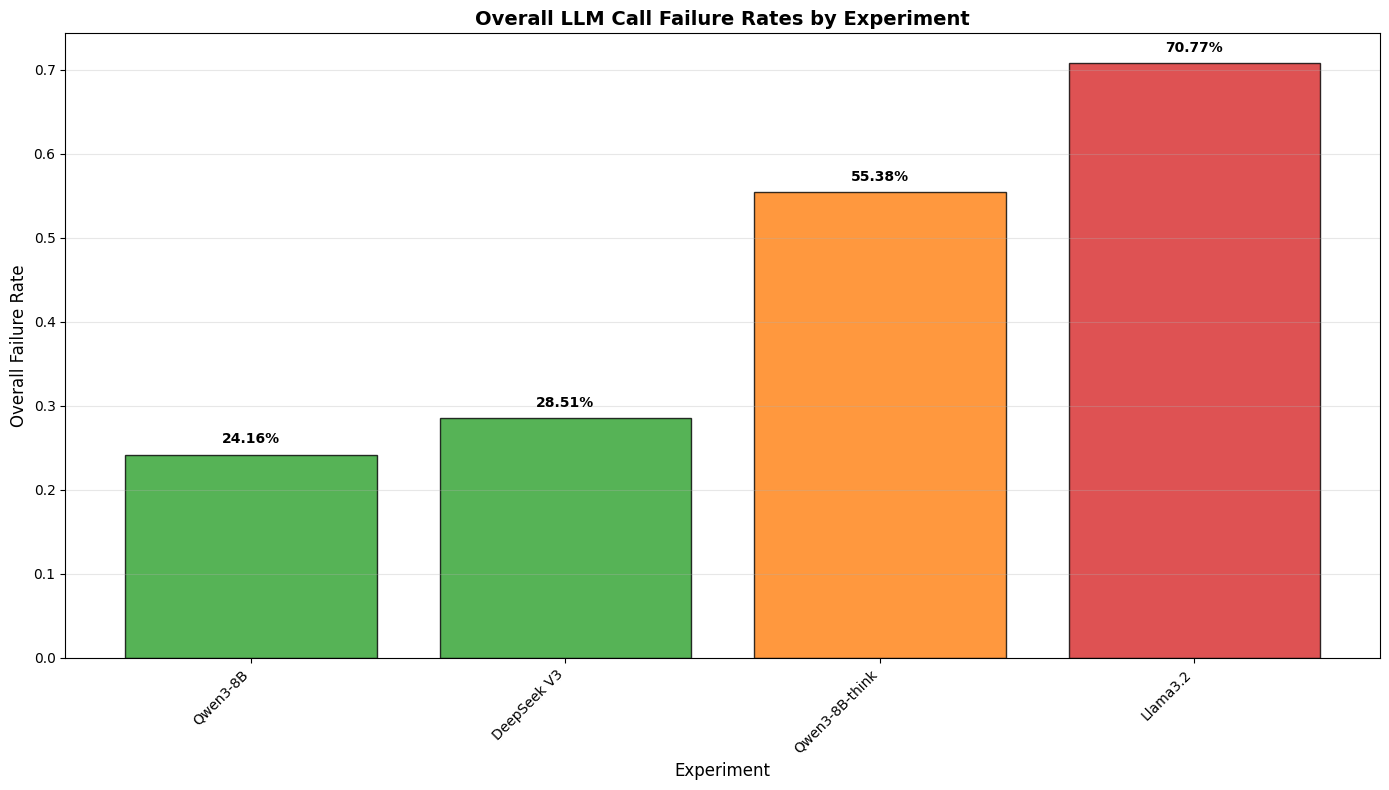

Saved plot to /Users/xiaobocheng/final_project/image/syn2/failure_plot/operation_type_failure_rates.png


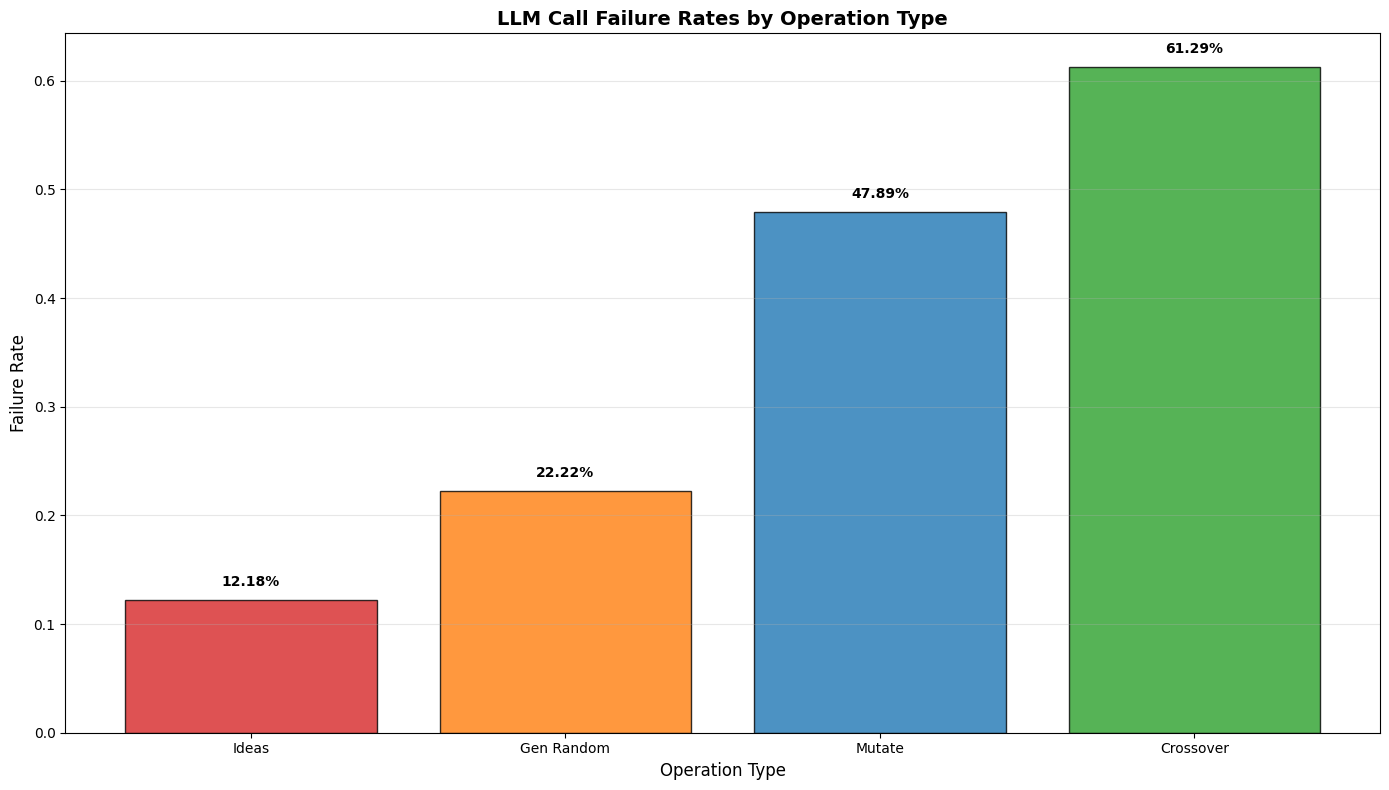

Saved plot to /Users/xiaobocheng/final_project/image/syn2/failure_plot/overall_failure_heatmap.png


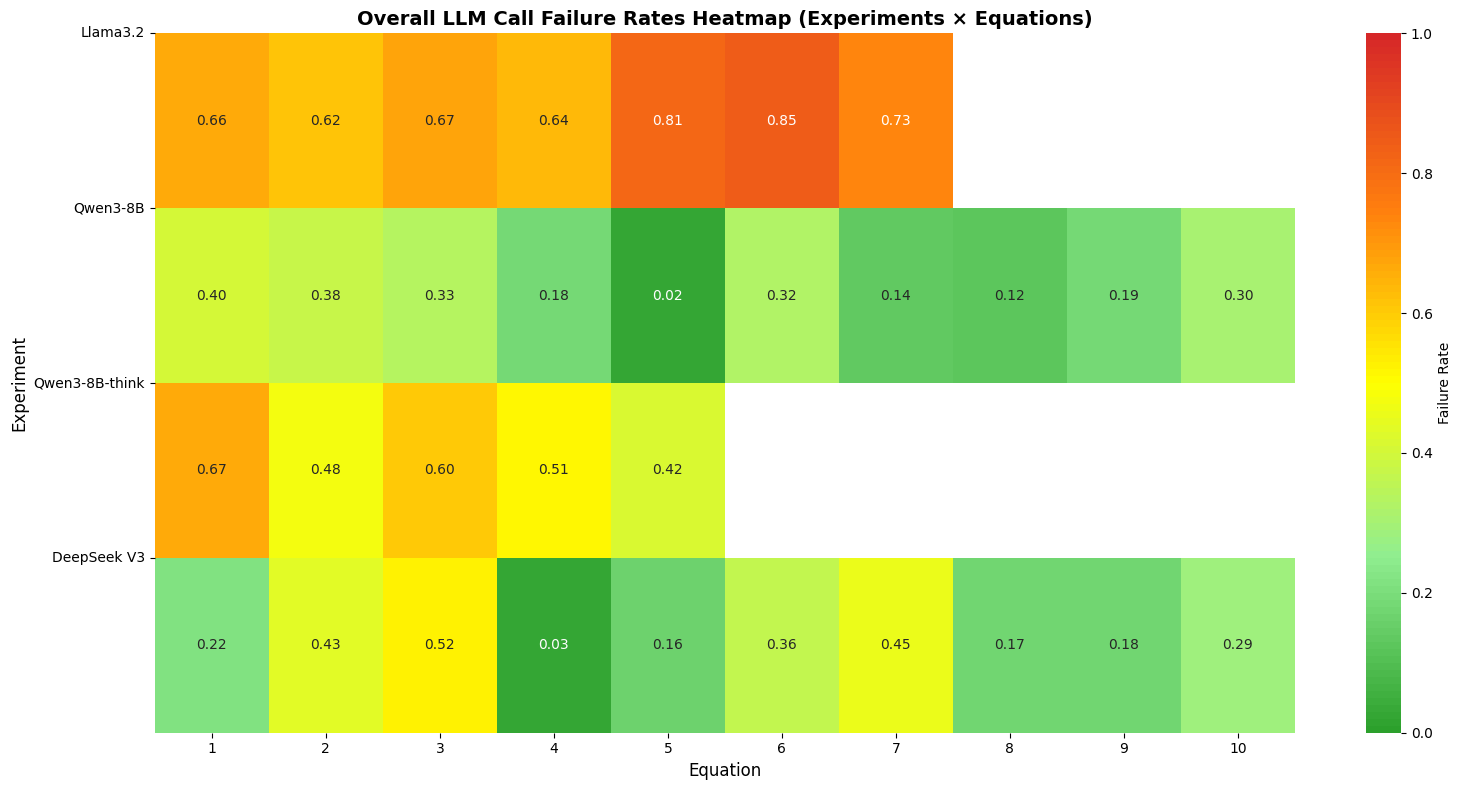


✅ All plots have been saved to the appropriate directories!
   - syn plots saved to: /Users/xiaobocheng/final_project/image/syn/
   - syn2 plots saved to: /Users/xiaobocheng/final_project/image/syn2/


In [198]:
# Create additional visualizations with save functionality

# 1. Overall failure rate comparison across experiments
plt.figure(figsize=(14, 8))
overall_failure_rates = method_summary_overall.sort_values('overall_failure_rate')
bars = plt.bar(range(len(overall_failure_rates)), overall_failure_rates['overall_failure_rate'], 
                color=['#2ca02c' if rate < 0.4 else '#ff7f0e' if rate < 0.6 else '#d62728' 
                       for rate in overall_failure_rates['overall_failure_rate']], 
                alpha=0.8, edgecolor='black')

# Add experiment labels
experiment_labels = [exp_labels.get(exp, f'Exp_{exp}') for exp in overall_failure_rates['experiment']]
plt.xticks(range(len(overall_failure_rates)), experiment_labels, rotation=45, ha='right')

plt.ylabel('Overall Failure Rate', fontsize=12)
plt.xlabel('Experiment', fontsize=12)
plt.title('Overall LLM Call Failure Rates by Experiment', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, rate) in enumerate(zip(bars, overall_failure_rates['overall_failure_rate'])):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{rate:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()

# Save the plot
save_path = f'/Users/xiaobocheng/final_project/image/{dataset_type}/overall_failure_rate_comparison.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved plot to {save_path}")

plt.show()

# 2. Operation type failure rate comparison
plt.figure(figsize=(14, 8))

operation_types = ['Ideas', 'Gen Random', 'Mutate', 'Crossover']
operation_rates = [
    total_ideas_failed/total_ideas if total_ideas > 0 else 0,
    total_gen_random_failed/total_gen_random if total_gen_random > 0 else 0,
    total_mutate_failed/total_mutate if total_mutate > 0 else 0,
    total_crossover_failed/total_crossover if total_crossover > 0 else 0
]

colors = ['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c']
bars = plt.bar(operation_types, operation_rates, color=colors, alpha=0.8, edgecolor='black')

plt.ylabel('Failure Rate', fontsize=12)
plt.xlabel('Operation Type', fontsize=12)
plt.title('LLM Call Failure Rates by Operation Type', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, rate in zip(bars, operation_rates):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{rate:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()

# Save the plot
save_path = f'/Users/xiaobocheng/final_project/image/{dataset_type}/operation_type_failure_rates.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved plot to {save_path}")

plt.show()

# 3. Heatmap of overall failure rates
plt.figure(figsize=(16, 8))
overall_heatmap = overall_failure_rate_table

# Create a custom colormap
import matplotlib.colors as mcolors
colors = ['#2ca02c', '#90ee90', '#ffff00', '#ff7f0e', '#d62728']
n_bins = 100
cmap = mcolors.LinearSegmentedColormap.from_list('custom', colors, N=n_bins)

sns.heatmap(overall_heatmap, annot=True, fmt='.2f', cmap=cmap, 
            cbar_kws={'label': 'Failure Rate'}, vmin=0, vmax=1)

# Add experiment labels
exp_labels_list = [exp_labels.get(i, f'Exp_{i}') for i in overall_heatmap.index]
plt.yticks(range(len(exp_labels_list)), exp_labels_list, rotation=0)

plt.title('Overall LLM Call Failure Rates Heatmap (Experiments × Equations)', fontsize=14, fontweight='bold')
plt.xlabel('Equation', fontsize=12)
plt.ylabel('Experiment', fontsize=12)

plt.tight_layout()

# Save the plot
save_path = f'/Users/xiaobocheng/final_project/image/{dataset_type}/overall_failure_heatmap.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved plot to {save_path}")

plt.show()

print("\n✅ All plots have been saved to the appropriate directories!")
print(f"   - syn plots saved to: /Users/xiaobocheng/final_project/image/syn/")
print(f"   - syn2 plots saved to: /Users/xiaobocheng/final_project/image/syn2/")